Загрузка и предобработка данных...


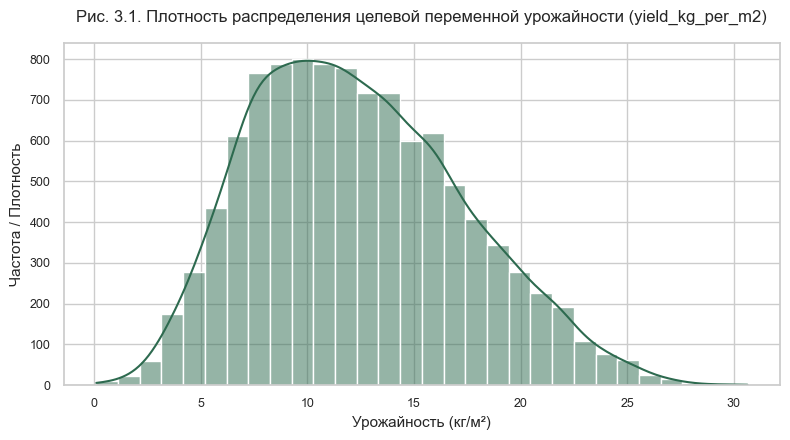

C:\Users\Fedya\AppData\Local\Temp\ipykernel_9392\2152795766.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='crop_type', y='yield_kg_per_m2', palette='Set2')


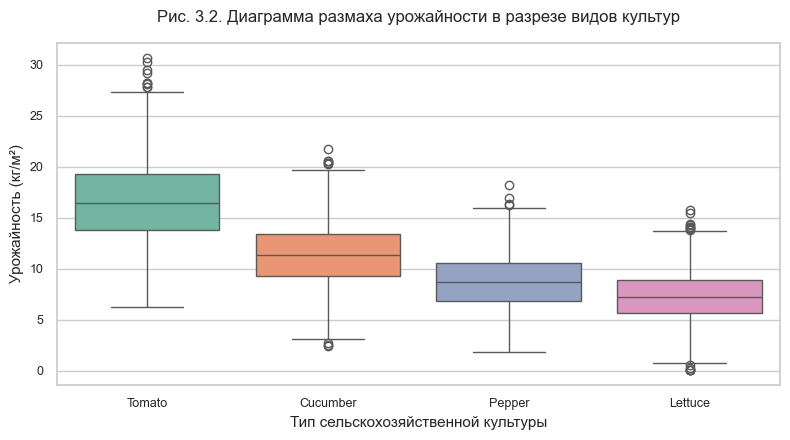

Выполнение Feature Engineering...


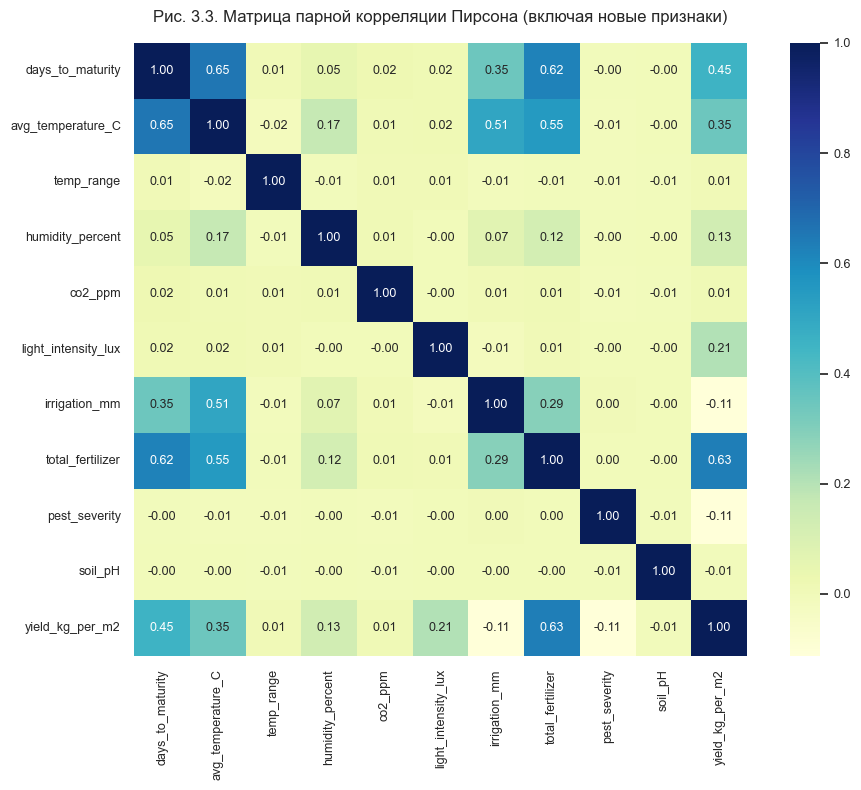

Обучение моделей машинного обучения...

=== БАҲОГУЗОРӢ (ОЦЕНКА МЕТРИК ЭФФЕКТИВНОСТИ) ===
Модель: Gradient Boosting -> MAE: 1.6717 | RMSE: 2.0899 | R²: 0.8171
Модель: Random Forest -> MAE: 1.6923 | RMSE: 2.1092 | R²: 0.8138


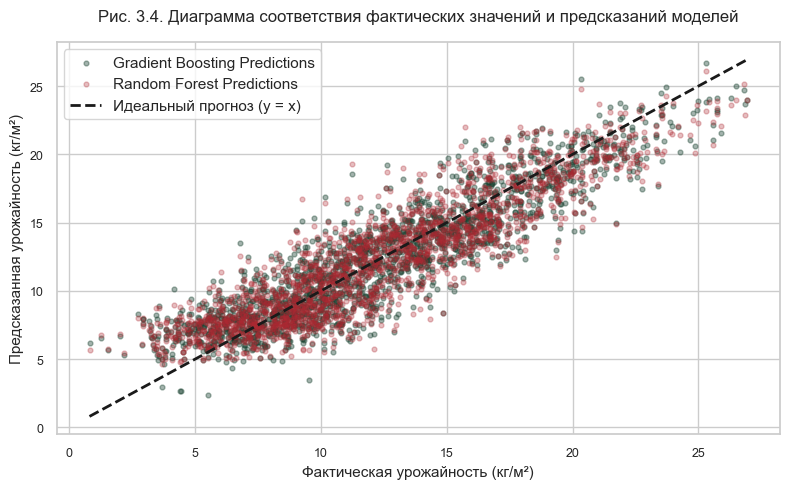

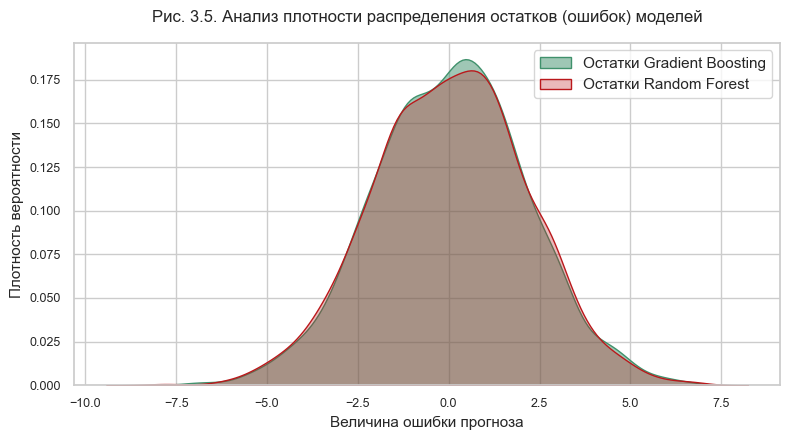

C:\Users\Fedya\AppData\Local\Temp\ipykernel_9392\2152795766.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


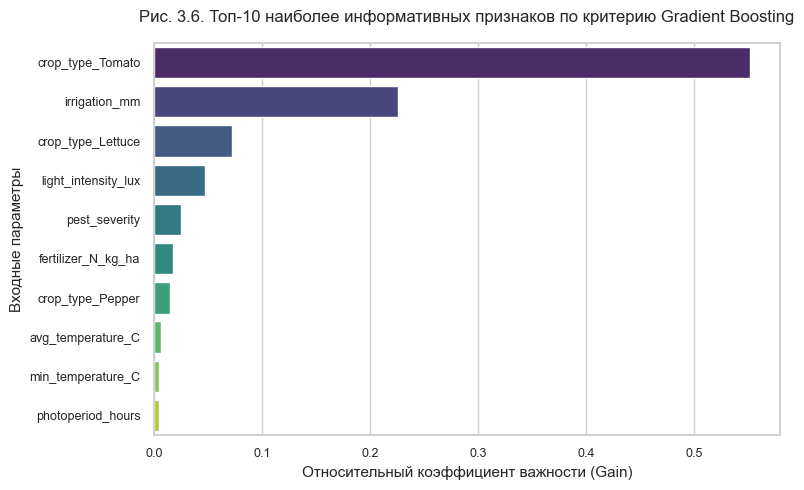

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Танзими услуби касбӣ барои графикҳои илмӣ
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})

# =====================================================================
# 1. БОРГУЗОРӢ ВА ПЕШКОРКАРДИ МАЪЛУМОТ (EDA)
# =====================================================================
print("Боргузорӣ ва пешкоркарди маълумот...")
df = pd.read_csv('greenhouse_crop_yields.csv')

# Пур кардани ҷойҳои холӣ дар факторҳои ададӣ бо нишондиҳандаҳои медианавӣ
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Визуализатсияи 1: Тақсимоти тағйирёбандаи мақсадноки ҳосилнокӣ
plt.figure(figsize=(8, 4.5))
sns.histplot(df['yield_kg_per_m2'], kde=True, color='#2d6a4f', bins=30)
plt.title('Расми 3.1. Зичии тақсимоти тағйирёбандаи мақсадноки ҳосилнокӣ (yield_kg_per_m2)', pad=15)
plt.xlabel('Ҳосилнокӣ (кг/м²)')
plt.ylabel('Такроршавӣ / Зичӣ')
plt.tight_layout()
plt.savefig('01_yield_distribution.png', dpi=300)
plt.show()

# Визуализатсияи 2: Вобастагии ҳосилнокӣ аз намуди зироат (Boxplot)
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='crop_type', y='yield_kg_per_m2', palette='Set2')
plt.title('Расми 3.2. Диаграммаи паҳноии ҳосилнокӣ дар буриши намудҳои зироат', pad=15)
plt.xlabel('Намуди зироати кишоварзӣ')
plt.ylabel('Ҳосилнокӣ (кг/м²)')
plt.tight_layout()
plt.savefig('02_crop_yield_boxplot.png', dpi=300)
plt.show()

# =====================================================================
# 2. ЛОИҲАКАШИИ АЛОМАТҲО (FEATURE ENGINEERING)
# =====================================================================
print("Иҷрои Feature Engineering...")
# Сохтани аломатҳои нави синтетикӣ дар асоси мантиқи агроклиматӣ
df['temp_range'] = df['max_temperature_C'] - df['min_temperature_C'] # Амплитудаи шабонарӯзии ҳарорат
df['total_fertilizer'] = df['fertilizer_N_kg_ha'] + df['fertilizer_P_kg_ha'] + df['fertilizer_K_kg_ha'] # Миқдори умумии NPK

# Визуализатсияи 3: Харитаи ҳароратии матритсаи коррелятсияи аломатҳо
plt.figure(figsize=(10, 8))
corr_cols = ['days_to_maturity', 'avg_temperature_C', 'temp_range', 'humidity_percent', 'co2_ppm', 
                 'light_intensity_lux', 'irrigation_mm', 'total_fertilizer', 'pest_severity', 'soil_pH', 'yield_kg_per_m2']
correlation_matrix = df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='YlGnBu', cbar=True, square=True, annot_kws={"size": 9})
plt.title('Расми 3.3. Матритсаи коррелятсияи ҷуфтии Пирсон (бо назардошти аломатҳои нав)', pad=15)
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=300)
plt.show()

# =====================================================================
# 3. ОМОДАГӢ БА ОМУЗИШ ВА ОMӮЗИШИ МОДЕЛҲО
# =====================================================================
# Истисно кардани идентификаторҳои техникӣ ва санаҳо
X = df.drop(columns=['greenhouse_id', 'planting_date', 'harvest_date', 'yield_kg_per_m2'])
# Татбиқи One-Hot Encoding барои аломатҳои категориявӣ (намуди зироат ва навъ)
X = pd.get_dummies(X, columns=['crop_type', 'variety'], drop_first=True)
y = df['yield_kg_per_m2']

# Тақсими интихоб ба омӯзишӣ ва тестрасонӣ (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Омӯзиши моделҳои омӯзиши мошинӣ...")
# Модель 1: Ансамбли Бустинги Градиентӣ
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_gb.fit(X_train, y_train)
pred_gb = model_gb.predict(X_test)

# Модель 2: Ансамбли Ҷангали Тасодуфӣ
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

# =====================================================================
# 4. ТАҲЛИЛИ МУҚОИШАВӢ ВА БАҲОГУЗОРИИ СИФАТ (БАҲОГУЗОРӢ)
# =====================================================================
print("\n=== БАҲОГУЗОРӢ (БАҲОГУЗОРИИ МЕТРИКАҲОИ САМАРАНОКӢ) ===")
for name, pred in [("Gradient Boosting", pred_gb), ("Random Forest", pred_rf)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"Модел: {name} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Визуализатсияи 4: Муқоисаи нишондиҳандаҳои воқеӣ ва пешгӯиҳо (Диаграммаи парокандагӣ)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_gb, alpha=0.4, color='#1b4332', label='Пешгӯиҳои Gradient Boosting', s=12)
plt.scatter(y_test, pred_rf, alpha=0.3, color='#ad2831', label='Пешгӯиҳои Random Forest', s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Пешгӯии идеалӣ (y = x)')
plt.title('Расми 3.4. Диаграммаи мувофиқати нишондиҳандаҳои воқеӣ ва пешгӯиҳои моделҳо', pad=15)
plt.xlabel('Ҳосилнокии воқеӣ (кг/м²)')
plt.ylabel('Ҳосилнокии пешгӯишуда (кг/м²)')
plt.legend()
plt.tight_layout()
plt.savefig('04_actual_vs_predicted.png', dpi=300)
plt.show()

# Визуализатсияи 5: Тақсимоти боқимондаҳо (Хатогиҳои пешгӯӣ)
plt.figure(figsize=(8, 4.5))
residuals_gb = y_test - pred_gb
residuals_rf = y_test - pred_rf
sns.kdeplot(residuals_gb, label='Боқимондаҳои Gradient Boosting', fill=True, color='#40916c', alpha=0.5)
sns.kdeplot(residuals_rf, label='Боқимондаҳои Random Forest', fill=True, color='#ba181b', alpha=0.3)
plt.title('Расми 3.5. Таҳлили зичии тақсимоти боқимондаҳо (хатогиҳо)-и моделҳо', pad=15)
plt.xlabel('Қимати хатогии пешгӯӣ')
plt.ylabel('Зичии эҳтимолӣ')
plt.legend()
plt.tight_layout()
plt.savefig('05_residuals_analysis.png', dpi=300)
plt.show()

# Визуализатсияи 6: Аҳамияти аломатҳо (Feature Importance)
plt.figure(figsize=(8, 5))
feat_importance = pd.Series(model_gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Расми 3.6. Топ-10 аломатҳои аз ҳама сермаълумот аз рӯи меъёри Gradient Boosting', pad=15)
plt.xlabel('Коэффисиенти нисбии аҳамият (Gain)')
plt.ylabel('Параметрҳои вурудӣ')
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=300)
plt.show()